# 심화 세션 - 추천 시스템 사전과제

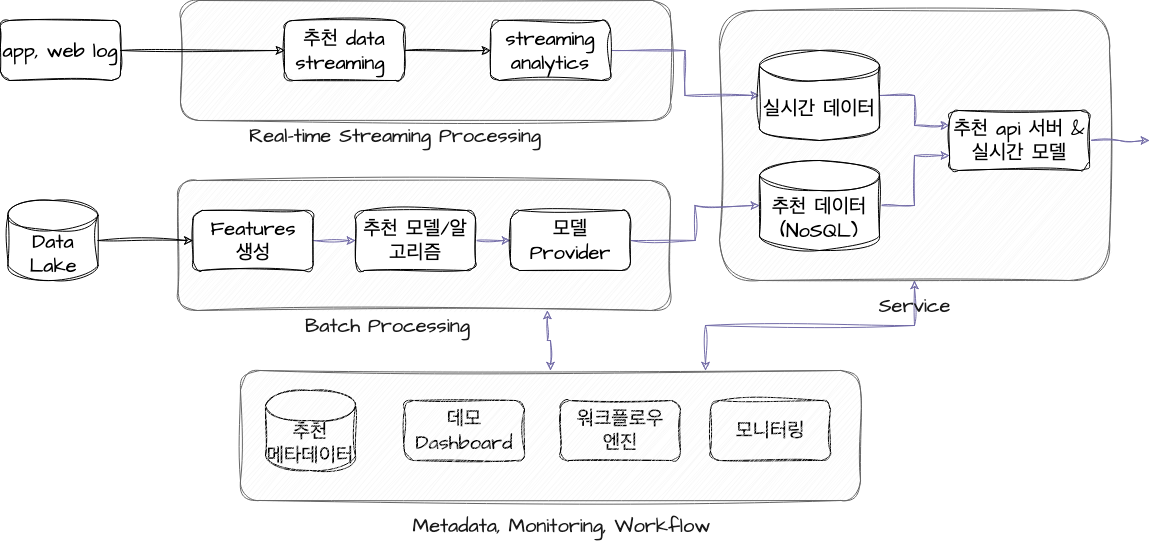

## 1. 추천 시스템의 분류

**추천 시스템** = 사용자가 좋아할 만한 아이템을 예측해서 제안하는 시스템
넷플릭스의 영화 추천, 유튜브의 다음 영상 추천, 쿠팡의 상품 추천 등

추천 방식은 크게 **내용 기반 필터링**과 **협업 필터링**으로 나뉨.

```
추천 시스템
 ├── 내용 기반 필터링
 └── 협업 필터링
      ├── 메모리 기반 협업 필터링
      └── 모델 기반 협업 필터링
```

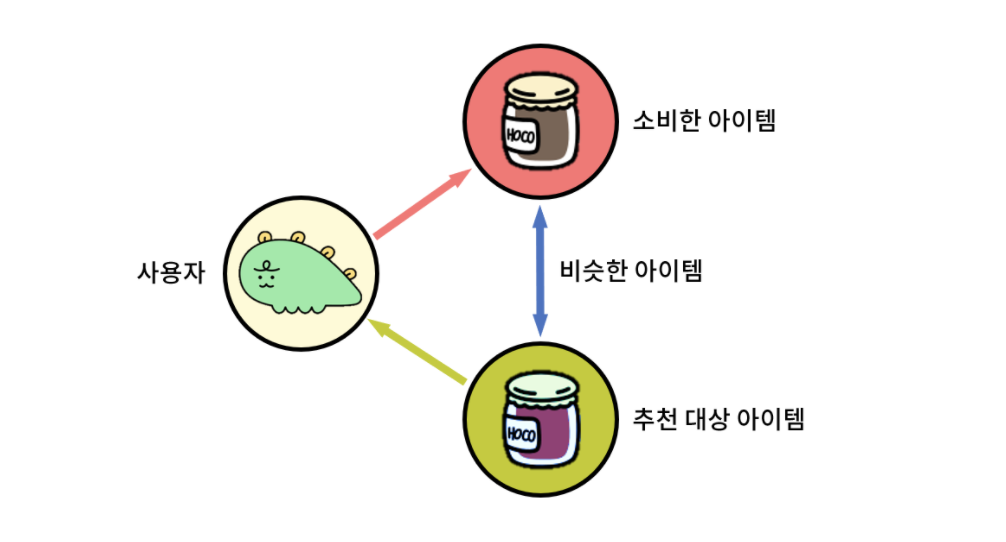

### 1-1. 내용 기반 필터링

**아이템의 속성, 내용** 을 분석해서, 사용자가 과거에 좋아했던 아이템과 **비슷한 속성**의 아이템을 추천하는 방식

**동작 방식:**
```
사용자가 "왕과 사는 남자" 시청
    │
    ▼
아이템 속성 분석: [고전, 역사, 단종]
    │
    ▼
유사한 속성의 아이템 검색
    │
    ▼
역사 관련 영화 추천
```

**장점:**
- 다른 사용자의 데이터 없이도 추천 가능
- 새로운 아이템도 속성만 있으면 바로 추천 가능 (Cold Start 문제 완화)
- 추천 이유를 설명하기 쉬움 ("당신이 SF 영화를 좋아하기 때문에...")

**단점:**
- 사용자가 기존에 좋아하던 것과 비슷한 것만 추천 -> **필터 버블** 문제
- 아이템 속성을 잘 정의하고 추출하는 것 자체가 어려울 수 있음
- 완전히 새로운 장르/카테고리의 아이템은 추천받기 어려움

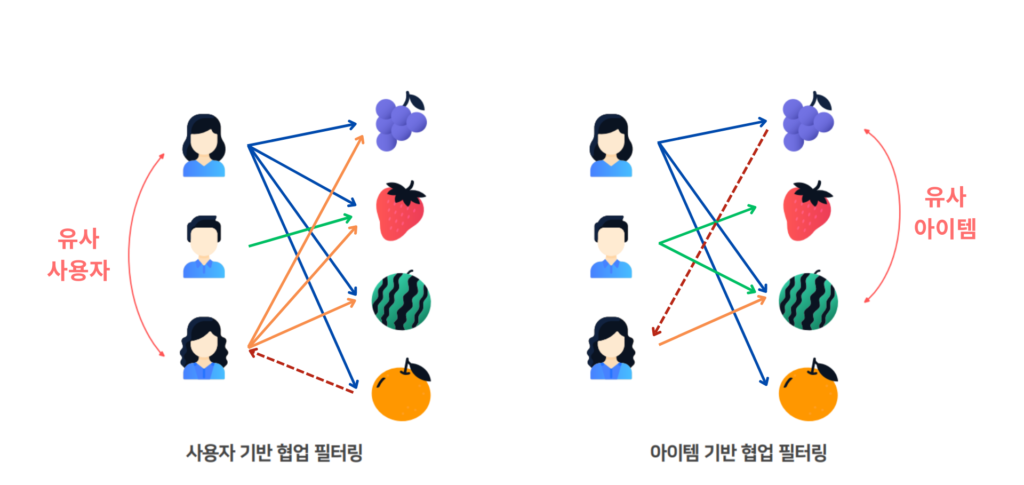

### 1-2. 협업 필터링

**"나와 비슷한 취향의 사람들이 좋아한 것을 나도 좋아할 것이다"** 는 아이디어에 기반한 방식임.  
아이템의 내용이 아니라 **사용자들의 행동 패턴** 을 활용함.

협업 필터링은 다시 **메모리 기반**과 **모델 기반**으로 나뉨.


#### 메모리 기반 협업 필터링

별도의 모델 학습 없이, **저장된 사용자-아이템 데이터를 직접 사용**해서 추천함.  
유사한 사용자나 아이템을 찾아 점수를 예측하는 방식임.

| 방식 | 설명 | 예시 |
|------|------|------|
| **사용자 기반** | 나와 비슷한 취향의 사용자를 찾고, 그 사람이 좋아한 아이템을 추천 | "A, B, C를 다 좋아하는 사람은 D도 좋아했음" |
| **아이템 기반** | 내가 좋아한 아이템과 유사한 아이템을 추천 | "X를 좋아한 사람들은 Y도 좋아함" |

**장점:** 구현이 단순하고 직관적임  
**단점:** 사용자/아이템 수가 많아지면 계산량이 폭발적으로 증가함


#### 모델 기반 협업 필터링

사용자-아이템 데이터를 기반으로 **머신러닝/딥러닝 모델을 학습**해서 추천함.  
데이터에서 패턴을 학습해두기 때문에 예측이 빠르고 확장성이 좋음.

대표적인 방법:
- **행렬 분해**
- **딥러닝 기반 모델**  (VAE, GNN, Transformer 등)

**장점:** 데이터가 많을수록 성능이 좋아짐, 확장성 우수  
**단점:** 모델 학습 비용이 필요하고, 추천 이유를 설명하기 어려울 수 있음


**내용 기반 vs 협업 필터링 비교**

| | 내용 기반 필터링 | 협업 필터링 |
|-|----------------|------------|
| 활용 데이터 | 아이템 속성 | 사용자 행동 데이터 |
| 다른 사용자 데이터 필요 여부 | 불필요 | 필요 |
| 새 아이템 추천 | 가능 | 어려움 (Cold Start) |
| 다양성 | 낮음 (비슷한 것만 추천) | 높음 |

## 2. 유사도

추천 시스템에서 "얼마나 비슷한가"를 수치로 측정하는 방법 
사용자 간 유사도, 아이템 간 유사도 계산에 모두 활용됨



### 코사인 유사도

두 벡터 사이의 **각도**를 이용해 유사도를 계산함.  
값의 크기보다 **방향(패턴)** 이 얼마나 비슷한지를 측정함.

$$\text{cosine similarity}(A, B) = \frac{A \cdot B}{|A||B|}$$

- 결과 범위: -1 ~ 1 (보통 추천에선 0 ~ 1)
- 1에 가까울수록 유사, 0에 가까울수록 무관
- 텍스트, 사용자 평점 벡터 비교에 많이 사용됨

**예시:**
```
사용자 A의 평점: [5, 3, 0, 1]  (영화1, 영화2, 영화3, 영화4)
사용자 B의 평점: [4, 3, 0, 2]
→ 코사인 유사도가 높으면 A와 B는 비슷한 취향
```



### 피어슨 상관계수

두 변수의 **선형 상관관계**를 측정함.  
사용자마다 평점의 기준이 다를 때(어떤 사람은 후하게, 어떤 사람은 엄격하게 줄 때) 유용함.

- 결과 범위: -1 ~ 1
- 평균을 빼고 계산하기 때문에 **평점 편향** 을 보정할 수 있음



### 유클리드 거리

두 벡터 사이의 **직선 거리**를 계산함.

$$d(A, B) = \sqrt{\sum_{i}(A_i - B_i)^2}$$

- 거리가 가까울수록 유사함
- 직관적이지만 벡터 차원이 커지면 성능이 떨어지는 경향이 있음 (차원의 저주)



**유사도 비교 요약**

| 유사도 | 특징 | 주로 사용하는 상황 |
|--------|------|------------------|
| 코사인 유사도 | 방향(패턴) 기반 | 텍스트, 평점 벡터 |
| 피어슨 상관계수 | 평균 편향 보정 | 사용자 간 평점 비교 |
| 유클리드 거리 | 절대적 거리 | 저차원 수치 데이터 |

## 3. 사용자 프로필

**사용자 프로필**은 추천 시스템이 사용자의 취향과 특성을 표현하는 방식임.  
사용자 프로필이 얼마나 잘 구성되어 있느냐에 따라 추천 품질이 크게 달라짐.



### 프로필 구성 요소

| 종류 | 내용 | 예시 |
|------|------|------|
| **명시적 데이터** | 사용자가 직접 제공한 정보 | 평점, 좋아요/싫어요, 관심 장르 선택 |
| **암묵적 데이터** | 사용자 행동에서 간접적으로 수집 | 클릭, 시청 시간, 구매 내역, 검색 기록 |
| **인구통계 정보** | 기본 개인 정보 | 나이, 성별, 지역 |

> 실제 서비스에서는 명시적 데이터보다 **암묵적 데이터**가 훨씬 많고 유용함.  
> 사용자가 직접 평점을 매기는 경우는 드물지만 클릭이나 시청 시간은 자동으로 수집되기 때문



### Cold Start 문제

사용자 프로필과 관련된 대표적인 문제임.

- **신규 사용자 Cold Start:** 데이터가 없어서 취향을 알 수 없음
- **신규 아이템 Cold Start:** 아무도 평가하지 않은 새 아이템은 추천되기 어려움

**해결 방법:**
- 가입 시 온보딩으로 초기 취향 수집
- 인구통계 정보 기반 초기 추천
- 내용 기반 필터링으로 보완

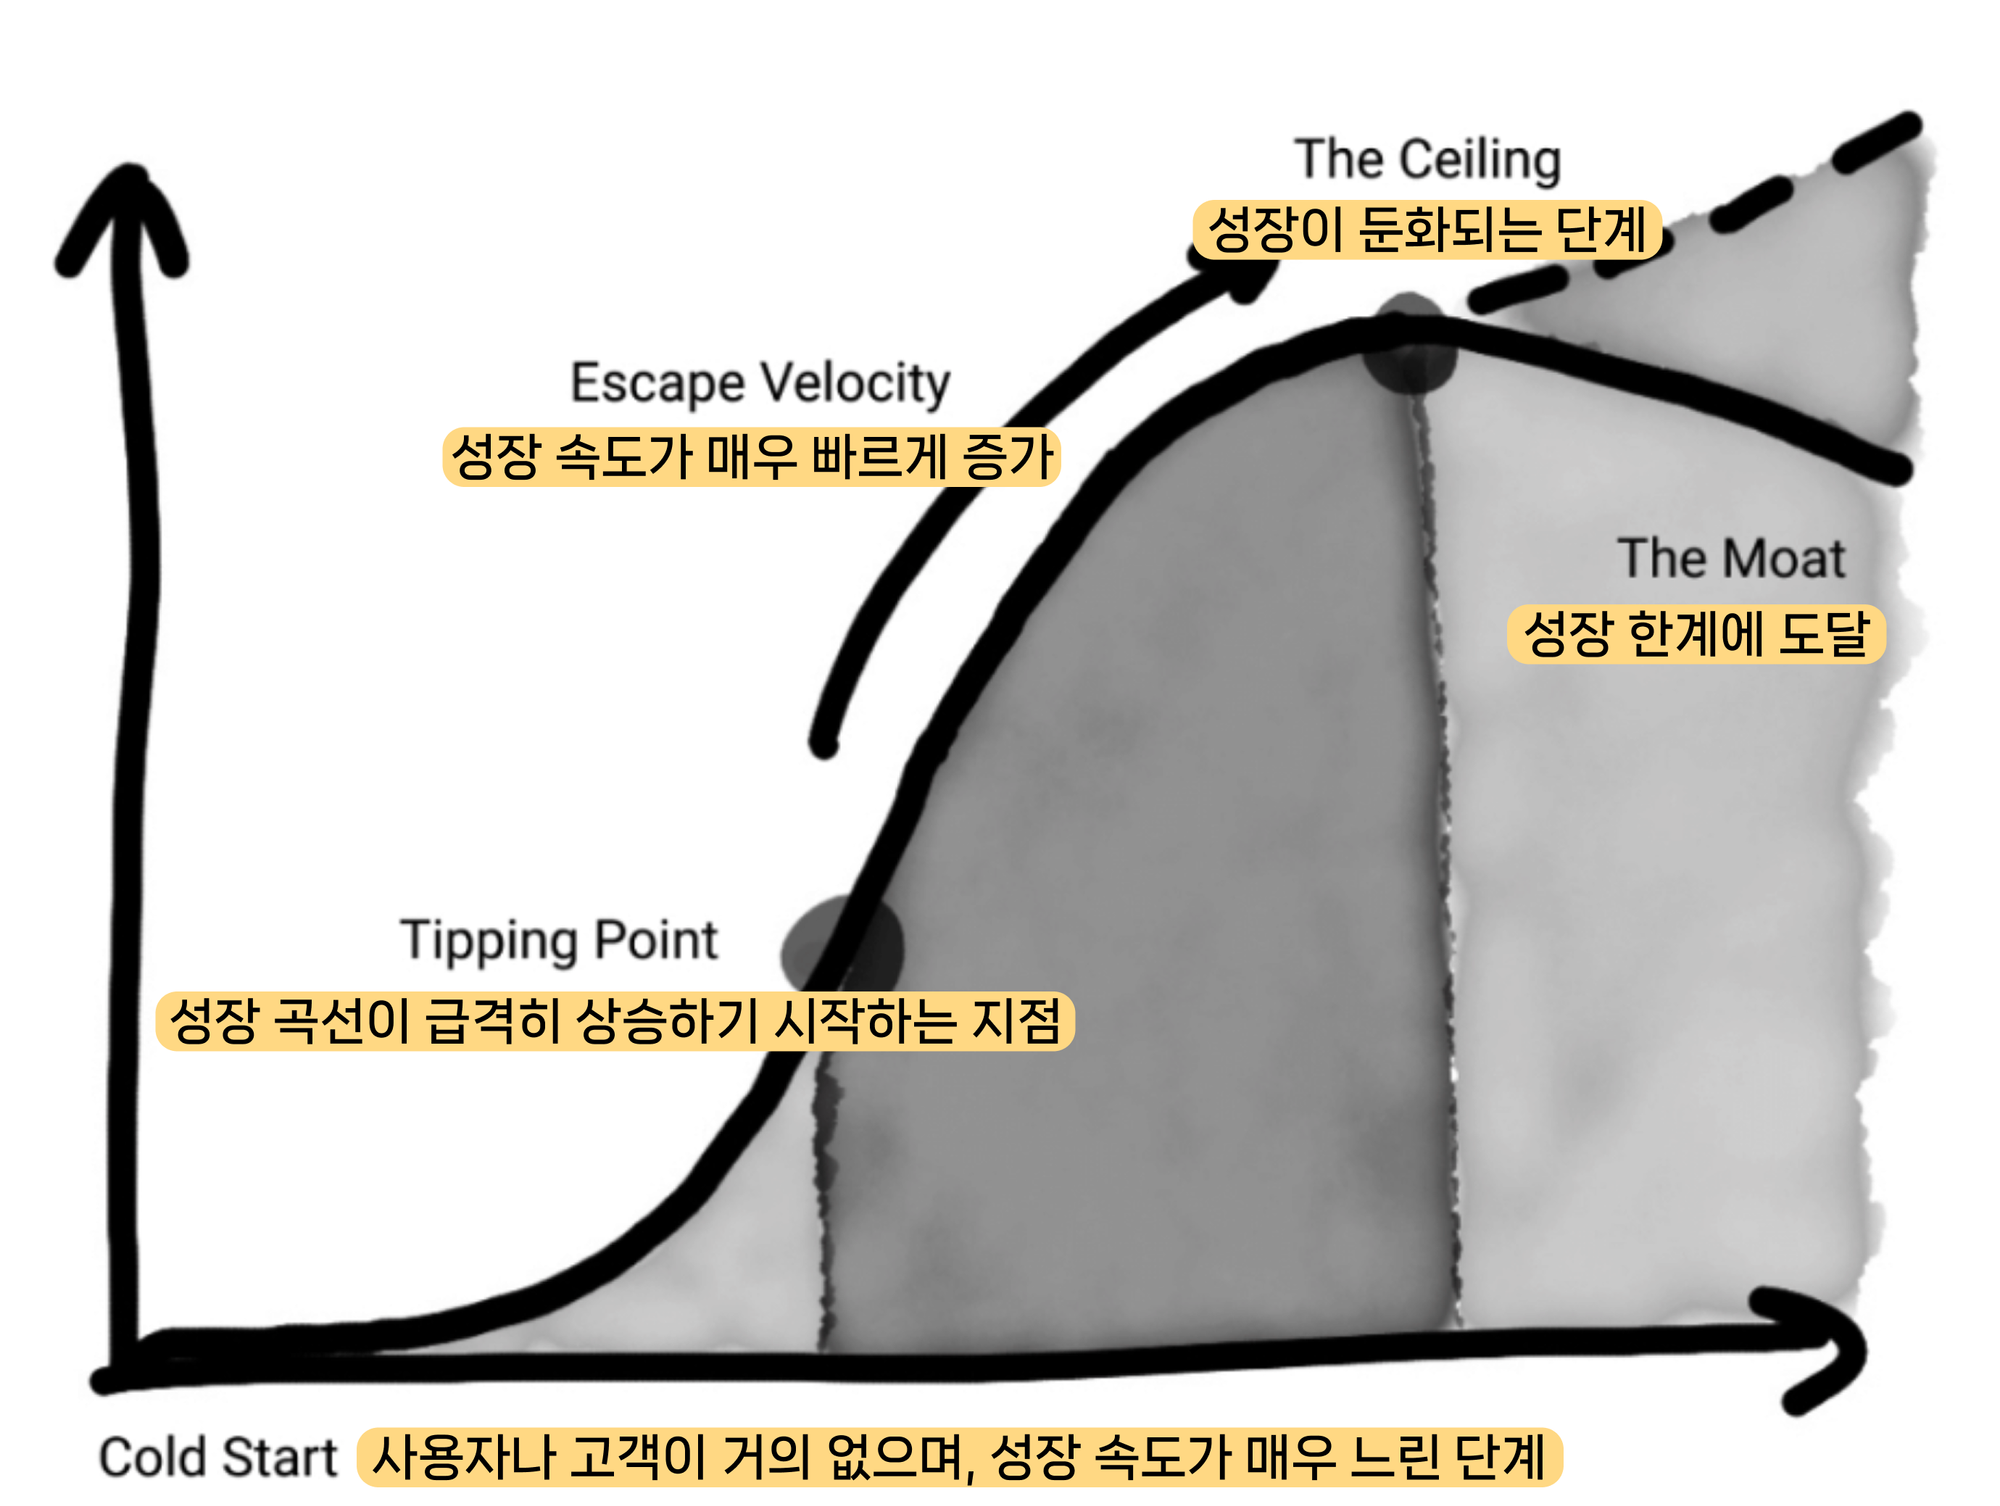

## 4. TF-IDF

**TF-IDF** 는 텍스트에서 단어의 중요도를 수치화하는 방법임.  
내용 기반 필터링에서 아이템의 텍스트 속성(설명, 태그, 리뷰 등)을 벡터로 변환할 때 많이 사용


### TF (Term Frequency, 단어 빈도)

특정 문서에서 단어가 **얼마나 자주 등장하는지** 를 측정함.

$$TF(t, d) = \frac{\text{단어 } t \text{가 문서 } d \text{에 등장한 횟수}}{\text{문서 } d \text{의 전체 단어 수}}$$

- "우주"라는 단어가 SF 영화 설명에 10번 나오면 TF가 높음
- 하지만 "이", "그", "은" 같은 단어도 자주 나오므로 TF만으로는 부족함



### IDF

단어가 **전체 문서에서 얼마나 희귀한지**를 측정함.  
많은 문서에 등장하는 흔한 단어("영화", "이야기")는 중요도를 낮추는 역할을 함.

$$IDF(t) = \log \frac{\text{전체 문서 수}}{\text{단어 } t \text{가 등장한 문서 수}}$$

- 모든 문서에 등장하면 IDF ≈ 0 (중요하지 않음)
- 소수의 문서에만 등장하면 IDF가 높음 (중요한 단어)



### TF-IDF 계산

$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

**예시:**
```
영화 설명 문서들이 있을 때,

"우주" → 특정 SF 영화에만 자주 등장 -> TF 높고, IDF 높음 -> TF-IDF 높음
"영화" → 모든 문서에 등장          -> TF 높지만, IDF 낮음  -> TF-IDF 낮음
```

TF-IDF로 계산된 벡터를 코사인 유사도로 비교하면, 내용이 비슷한 아이템을 찾을 수 있음.

## 5. 행렬 분해

**행렬 분해**는 모델 기반 협업 필터링의 핵심 기법임.  
사용자-아이템 평점 행렬을 분석해 **잠재적인 취향 요인**을 찾아내는 방법임.

**요약**

사용자-아이템 행렬 R(m×n)은 대부분 빈칸(평점 없음)이 많은 **희소 행렬(Sparse Matrix)** 임.  
이를 두 개의 작은 행렬 P(사용자 잠재 벡터)와 Q(아이템 잠재 벡터)로 분해함.


잠재 요인 k는 "액션을 좋아하는 정도", "로맨스를 좋아하는 정도" 같은 추상적인 취향 축으로 해석할 수 있음. (자동으로 학습됨)


### 행렬 분해의 대표적 방식

**1. SVD (특이값 분해)**
- 행렬을 세 개의 행렬(U, Σ, Vᵀ)로 분해하는 수학적 방법
- 결측값(빈칸)이 없어야 적용 가능 -> 추천 시스템에 그대로 쓰기 어려움
- 이론적 기반을 제공한 방법

**2. SGD 기반 MF**
- 알려진 평점과 예측 평점의 차이(오차)를 최소화하도록 P, Q를 반복 업데이트
- 결측값을 무시하고 학습 가능 -> 실제 추천 시스템에 적합함
- 넷플릭스 프라이즈 대회에서 우수한 성능을 보여 유명해짐

**3. ALS**
- P를 고정하고 Q를 최적화, Q를 고정하고 P를 최적화하는 과정을 번갈아 반복
- **병렬 처리에 유리** -> 대규모 분산 환경(Spark 등)에서 많이 사용됨
- 암묵적 피드백(클릭, 시청 등) 데이터에도 잘 적용됨

**4. BPR**
- 절대적인 평점 예측 대신 **아이템 간의 상대적 선호 순서**를 학습
- "사용자가 A보다 B를 더 좋아한다"는 쌍 데이터를 활용
- 암묵적 피드백 기반 추천에서 자주 쓰임

| 방식 | 특징 | 적합한 상황 |
|------|------|------------|
| SVD | 수학적으로 엄밀, 결측값 처리 어려움 | 이론 학습용 |
| SGD 기반 MF | 유연하고 성능 좋음 | 명시적 평점 데이터 |
| ALS | 병렬 처리 용이 | 대규모 암묵적 피드백 |
| BPR | 순위 학습에 특화 | 암묵적 피드백, 랭킹 최적화 |

## 6. 딥러닝 기반 추천 모델


### 6-1. VAE 기반 모델

생성 모델인 VAE를 추천 시스템에 활용한 방식  
대표 모델: **Mult-VAE**

**동작 방식**
```
사용자의 클릭/구매 기록
      │
      ▼
   [인코더]
      │  잠재 벡터 z (사용자 취향 표현)
      ▼
   [디코더]
      │
      ▼
모든 아이템에 대한 선호도 점수 예측 -> 상위 N개 추천
```

**특징**
- 사용자의 소비 기록을 잠재 벡터로 압축해 취향을 표현
- VAE의 확률적 특성 덕분에 **다양한 추천** 가능
- 암묵적 피드백(클릭, 구매) 데이터에 적합
- 행렬 분해보다 **비선형적인 사용자 취향** 패턴을 포착할 수 있음

### 6-2. GNN 기반 모델

사용자-아이템 관계를 **그래프**로 표현하고, GNN으로 학습하는 방식
대표 모델: **LightGCN**

**요약**

사용자와 아이템을 노드로, 상호작용(구매, 클릭)을 엣지로 표현

```
사용자 A ──── 아이템 1
         \── 아이템 2
사용자 B ──── 아이템 2
         \── 아이템 3
```

GNN은 각 노드의 임베딩을 이웃 노드의 정보를 집계해서 업데이트함.  
즉 "A가 구매한 아이템을 B도 구매했다"는 고차원적인 관계를 학습할 수 있음

**장점:**
- 사용자-아이템 간의 **고차원 연결 관계** 포착
- 소셜 네트워크, 지식 그래프 등 다양한 부가 정보를 쉽게 통합 가능
- 협업 필터링의 핵심인 "비슷한 이웃" 정보를 자연스럽게 학습

### 6-3. Transformer 기반 모델

NLP에서 큰 성공을 거둔 Transformer를 추천 시스템에 적용한 방식  
대표 모델: **BERT4Rec, SASRec**

**요약**

사용자의 아이템 소비 이력을 **시퀀스(순서가 있는 데이터)** 로 보고, Transformer로 다음 아이템을 예측함.

```
사용자 행동 시퀀스:
[아이템A 클릭] -> [아이템B 구매] -> [아이템C 조회] -> [다음은?]

Transformer의 Self-Attention이 "아이템A를 본 것이 다음 추천에 얼마나 영향을 미치는가"를 학습
```

**장점**
- **순서와 맥락** 을 반영한 추천 가능 ("최근에 운동화를 샀으니 운동복을 추천")
- Self-Attention으로 시퀀스 내 장거리 의존성 포착
- 사전학습 + 파인튜닝 패러다임 적용 가능

**단점**
- 연산량이 많아 실시간 서빙에 최적화가 필요함
- 행동 이력이 짧은 신규 사용자에게는 효과가 제한됨



**비교**

| 모델 | 핵심 구조 | 강점 |
|------|----------|------|
| VAE 기반 | 인코더-디코더, 확률적 잠재 공간 | 다양성, 암묵적 피드백 처리 |
| GNN 기반 | 그래프 노드-엣지 구조 | 고차원 관계, 부가 정보 통합 |
| Transformer 기반 | Self-Attention, 시퀀스 모델링 | 순서/맥락 반영, 장거리 의존성 |

# 감사합니다 ~~